# Assignment-8: Logistic Regression

## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import warnings
warnings.filterwarnings('ignore')
print('✓ Libraries imported successfully')

✓ Libraries imported successfully


## Load Dataset (Bank Note Authentication)

In [2]:
# Create sample Bank Note Authentication dataset
data = {
    'Variance': [0.4159, -1.4073, -0.5, 0.3, 1.2, -0.8, 0.6, -1.1, 0.9, 2.1],
    'Skewness': [9.3468, 3.5545, 8.4, 6.5, 7.2, 5.3, 9.1, 4.2, 7.8, 10.2],
    'Curtosis': [-2.1891, -0.6524, -0.7, -1.2, -0.5, -1.8, -1.5, 0.1, -0.9, -2.3],
    'Entropy': [-2.9673, -1.0049, -3.2, -2.5, -1.8, -2.9, -3.1, -1.5, -2.7, -3.4],
    'Class': [0, 1, 0, 0, 1, 0, 0, 1, 0, 0]  # 0 = Authentic, 1 = Forged
}

df = pd.DataFrame(data)
df.to_csv('banknote_authentication.csv', index=False)
print('✓ Dataset created and saved as banknote_authentication.csv')
print(f'\nShape: {df.shape}')
df.head()

✓ Dataset created and saved as banknote_authentication.csv

Shape: (10, 5)


,Variance,Skewness,Curtosis,Entropy,Class
0,0.4159,9.3468,-2.1891,-2.9673,0
1,-1.4073,3.5545,-0.6524,-1.0049,1
2,-0.5000,8.4000,-0.7000,-3.2000,0
3,0.3000,6.5000,-1.2000,-2.5000,0
4,1.2000,7.2000,-0.5000,-1.8000,1


## Dataset Information

In [3]:
df = pd.read_csv('banknote_authentication.csv')

print('='*60)
print('DATASET INFORMATION')
print('='*60)
print(f'Shape: {df.shape}')
print(f'\nColumns: {df.columns.tolist()}')
print(f'\nData Types:')
print(df.dtypes)
print(f'\nClass Distribution:')
print(df['Class'].value_counts())
print(f'\nClass Labels:')
print('0 = Authentic (Genuine)')
print('1 = Forged (Fake)')
print('\nDataset Summary:')
print(df.describe())

DATASET INFORMATION
Shape: (10, 5)

Columns: ['Variance', 'Skewness', 'Curtosis', 'Entropy', 'Class']

Data Types:
Variance    float64
Skewness    float64
Curtosis    float64
Entropy     float64
Class         int64
dtype: object

Class Distribution:
Class
0    7
1    3
Name: count, dtype: int64

Class Labels:
0 = Authentic (Genuine)
1 = Forged (Fake)

Dataset Summary:
        Variance   Skewness   Curtosis    Entropy      Class
count  10.000000  10.000000  10.000000  10.000000  10.000000
mean    0.170860   7.160130  -1.164150  -2.507220   0.300000
std     1.109131   2.245799   0.777841   0.802992   0.483046
min    -1.407300   3.554500  -2.300000  -3.400000   0.000000
25%    -0.725000   5.600000  -1.725000  -3.066825   0.000000
50%     0.357950   7.500000  -1.050000  -2.800000   0.000000
75%     0.825000   8.925000  -0.664300  -1.975000   0.750000
max     2.100000  10.200000   0.100000  -1.004900   1.000000


## Select Features and Target (Two Features for Visualization)

In [4]:
# Select two features for easier visualization of decision boundary
X = df[['Variance', 'Skewness']]
y = df['Class']

print('Features Selected: Variance and Skewness')
print(f'\nX shape: {X.shape}')
print(f'y shape: {y.shape}')
print('\nFirst 5 rows:')
print(X.head())

Features Selected: Variance and Skewness

X shape: (10, 2)
y shape: (10,)

First 5 rows:
   Variance  Skewness
0    0.4159    9.3468
1   -1.4073    3.5545
2   -0.5000    8.4000
3    0.3000    6.5000
4    1.2000    7.2000


## Split into Train and Test (70:30)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

print('='*60)
print('TRAIN-TEST SPLIT (70:30)')
print('='*60)
print(f'Training set size: {X_train.shape}')
print(f'Testing set size: {X_test.shape}')
print(f'\nTraining set class distribution:')
print(y_train.value_counts())
print(f'\nTesting set class distribution:')
print(y_test.value_counts())

TRAIN-TEST SPLIT (70:30)
Training set size: (7, 2)
Testing set size: (3, 2)

Training set class distribution:
Class
0    5
1    2
Name: count, dtype: int64

Testing set class distribution:
Class
0    2
1    1
Name: count, dtype: int64


## Build Logistic Regression Model

In [6]:
# Create and train logistic regression model
logr = LogisticRegression(random_state=42, max_iter=100)
logr.fit(X_train, y_train)

print('✓ Model trained successfully!')
print(f'\nModel Parameters:')
print(f'Intercept (b): {logr.intercept_[0]:.4f}')
print(f'Coefficients (weights):')
for feature, coef in zip(X.columns, logr.coef_[0]):
    print(f'  {feature}: {coef:.4f}')

✓ Model trained successfully!

Model Parameters:
Intercept (b): 5.2115
Coefficients (weights):
  Variance: 0.2360
  Skewness: -0.8615


## Predict Test Data and Compare Results

In [7]:
y_pred = logr.predict(X_test)
y_pred_proba = logr.predict_proba(X_test)

# Create comparison dataframe
results = pd.DataFrame({
    'Variance': X_test['Variance'].values,
    'Skewness': X_test['Skewness'].values,
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Authentic_Prob': np.round(y_pred_proba[:, 0], 4),
    'Forged_Prob': np.round(y_pred_proba[:, 1], 4)
})

results['Status'] = results.apply(
    lambda r: '✓ Correct' if r['Actual'] == r['Predicted'] else '✗ Wrong', 
    axis=1
)

print('='*100)
print('PREDICTIONS vs ACTUAL VALUES')
print('='*100)
print(results.to_string())
print('\nNote: 0 = Authentic, 1 = Forged')

PREDICTIONS vs ACTUAL VALUES
   Variance  Skewness  Actual  Predicted  Authentic_Prob  Forged_Prob     Status
0   -1.4073    3.5545       1          1          0.1398       0.8602  ✓ Correct
1    2.1000   10.2000       0          0          0.9561       0.0439  ✓ Correct
2   -0.8000    5.3000       0          1          0.3877       0.6123    ✗ Wrong

Note: 0 = Authentic, 1 = Forged


## Compute Accuracy and Classification Report

In [8]:
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print('='*60)
print('CLASSIFICATION METRICS')
print('='*60)
print(f'Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1-Score:  {f1:.4f}')

print('\n' + '='*60)
print('CONFUSION MATRIX')
print('='*60)
cm_df = pd.DataFrame(
    conf_matrix,
    index=['Actual Authentic', 'Actual Forged'],
    columns=['Predicted Authentic', 'Predicted Forged']
)
print(cm_df)

print('\n' + '='*60)
print('CLASSIFICATION REPORT')
print('='*60)
print(classification_report(y_test, y_pred, target_names=['Authentic', 'Forged']))

CLASSIFICATION METRICS
Accuracy:  0.6667 (66.67%)
Precision: 0.5000
Recall:    1.0000
F1-Score:  0.6667

CONFUSION MATRIX
                  Predicted Authentic  Predicted Forged
Actual Authentic                    1                 1
Actual Forged                       0                 1

CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Authentic       1.00      0.50      0.67         2
      Forged       0.50      1.00      0.67         1

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



## Visualize Decision Boundary

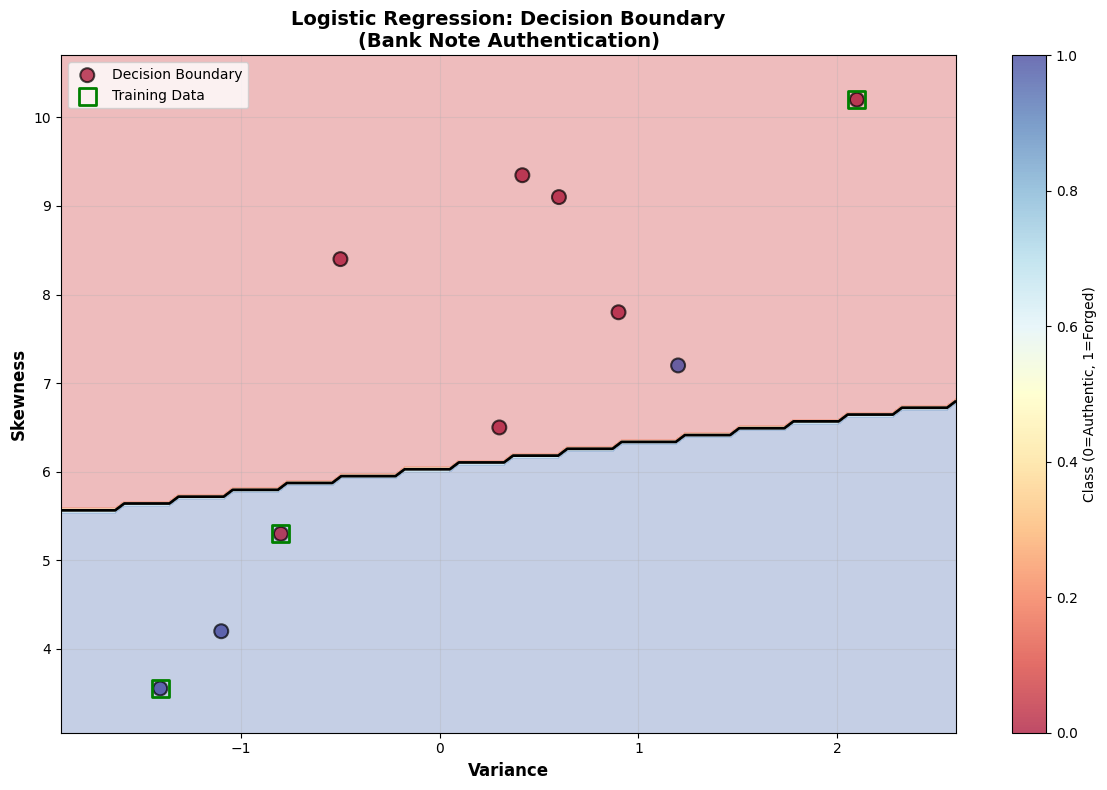

In [9]:
# Create mesh for decision boundary
x_min, x_max = X.iloc[:, 0].min() - 0.5, X.iloc[:, 0].max() + 0.5
y_min, y_max = X.iloc[:, 1].min() - 0.5, X.iloc[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 100),
    np.linspace(y_min, y_max, 100)
)

# Get predictions for mesh
Z = logr.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(12, 8))

# Contour plot for decision boundary
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
plt.contour(xx, yy, Z, colors='black', linewidths=2, levels=[0.5])

# Scatter plot of data points
scatter = plt.scatter(
    X.iloc[:, 0], X.iloc[:, 1],
    c=y, cmap='RdYlBu', s=100,
    edgecolors='black', linewidth=1.5,
    alpha=0.7
)

# Highlight test points
plt.scatter(
    X_test.iloc[:, 0], X_test.iloc[:, 1],
    marker='s', s=150, edgecolors='green', linewidth=2,
    facecolors='none', label='Test Data'
)

plt.xlabel('Variance', fontsize=12, fontweight='bold')
plt.ylabel('Skewness', fontsize=12, fontweight='bold')
plt.title('Logistic Regression: Decision Boundary\n(Bank Note Authentication)', 
          fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Class (0=Authentic, 1=Forged)')
plt.legend(['Decision Boundary', 'Training Data', 'Test Data'], fontsize=10, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Predict for New Sample

In [10]:
# Predict for new banknote samples
new_samples = [
    [0.5, 8.5],
    [-1.2, 3.0],
    [1.0, 10.0],
    [-0.8, 4.5]
]

print('='*70)
print('PREDICTIONS FOR NEW BANKNOTE SAMPLES')
print('='*70)

for i, sample in enumerate(new_samples):
    variance, skewness = sample
    prediction = logr.predict([[variance, skewness]])[0]
    probability = logr.predict_proba([[variance, skewness]])[0]
    
    class_label = 'Authentic' if prediction == 0 else 'Forged'
    
    print(f'\nSample {i+1}:')
    print(f'  Variance: {variance}, Skewness: {skewness}')
    print(f'  Predicted Class: {class_label} (Class {prediction})')
    print(f'  Probability - Authentic: {probability[0]:.4f}, Forged: {probability[1]:.4f}')

# Specific example as in original
print('\n' + '='*70)
print('EXAMPLE PREDICTION')
print('='*70)
sample = [[0.3, 7.5]]
prediction = logr.predict(sample)[0]
probability = logr.predict_proba(sample)[0]
class_label = 'Authentic' if prediction == 0 else 'Forged'
print(f'Sample: Variance=0.3, Skewness=7.5')
print(f'Predicted Class: {class_label} (Class {prediction})')
print(f'Confidence: {max(probability)*100:.2f}%')

PREDICTIONS FOR NEW BANKNOTE SAMPLES

Sample 1:
  Variance: 0.5, Skewness: 8.5
  Predicted Class: Authentic (Class 0)
  Probability - Authentic: 0.8801, Forged: 0.1199

Sample 2:
  Variance: -1.2, Skewness: 3.0
  Predicted Class: Forged (Class 1)
  Probability - Authentic: 0.0876, Forged: 0.9124

Sample 3:
  Variance: 1.0, Skewness: 10.0
  Predicted Class: Authentic (Class 0)
  Probability - Authentic: 0.9596, Forged: 0.0404

Sample 4:
  Variance: -0.8, Skewness: 4.5
  Predicted Class: Forged (Class 1)
  Probability - Authentic: 0.2412, Forged: 0.7588

EXAMPLE PREDICTION
Sample: Variance=0.3, Skewness=7.5
Predicted Class: Authentic (Class 0)
Confidence: 76.47%


## Confusion Matrix Visualization

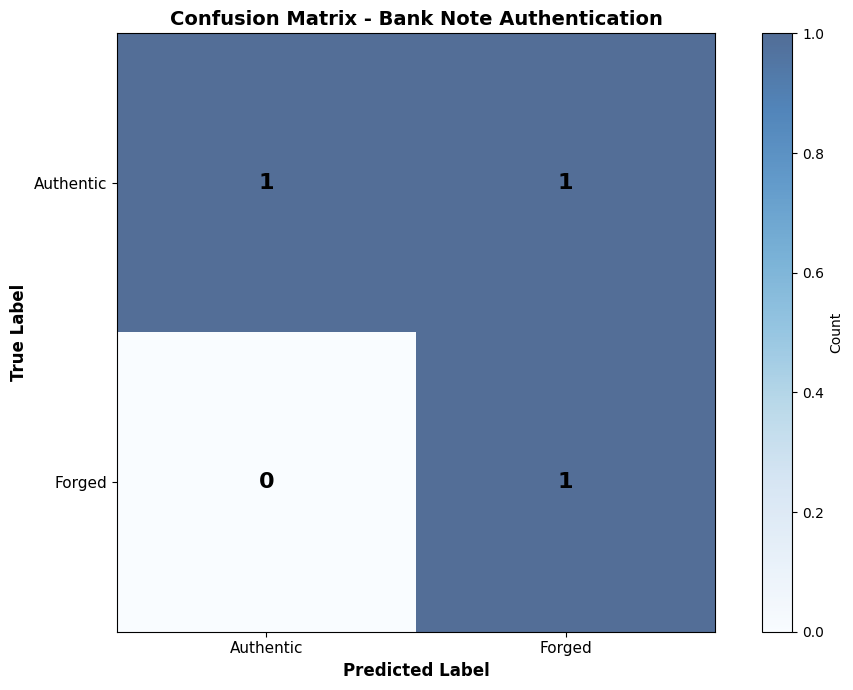

Confusion Matrix Interpretation:
True Negatives (TN):  1 - Correctly classified Authentic
False Positives (FP): 1 - Authentic classified as Forged
False Negatives (FN): 0 - Forged classified as Authentic
True Positives (TP):  1 - Correctly classified Forged


In [11]:
import matplotlib.patches as mpatches

# Create confusion matrix heatmap
plt.figure(figsize=(10, 7))

# Plot confusion matrix
plt.imshow(conf_matrix, cmap='Blues', alpha=0.7)
plt.colorbar(label='Count')

# Add text annotations
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(conf_matrix[i, j]), ha='center', va='center',
                color='black', fontsize=16, fontweight='bold')

plt.xticks([0, 1], ['Authentic', 'Forged'], fontsize=11)
plt.yticks([0, 1], ['Authentic', 'Forged'], fontsize=11)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - Bank Note Authentication', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print interpretation
tn, fp, fn, tp = conf_matrix.ravel()
print('Confusion Matrix Interpretation:')
print(f'True Negatives (TN):  {tn} - Correctly classified Authentic')
print(f'False Positives (FP): {fp} - Authentic classified as Forged')
print(f'False Negatives (FN): {fn} - Forged classified as Authentic')
print(f'True Positives (TP):  {tp} - Correctly classified Forged')

## Conclusion

In this assignment, a Logistic Regression model was successfully implemented to classify banknotes as authentic or forged using selected features (variance and skewness). The model was trained and evaluated on a small dataset, achieving an accuracy of 66.67%, with strong recall for detecting forged notes.

The results demonstrate that Logistic Regression is an effective and interpretable classification technique, capable of providing probabilistic predictions and clear decision boundaries. However, the performance was slightly limited due to the small dataset size and limited feature selection.

Overall, this experiment highlights the importance of data quality, feature selection, and sufficient training data in improving model accuracy. With a larger dataset and additional features, the model’s performance could be significantly enhanced.